In [1]:
#1

#importing different libraries for the analysis(from the regression notebook)
import numpy as np
import pandas as pd
import statsmodels.api as sm

from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import reset_ramsey
from statsmodels.graphics.regressionplots import plot_partregress_grid

import scipy.stats as stats
from scipy.stats import shapiro

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = "insurance.csv"
df = pd.read_csv(path)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print(df.duplicated().sum())
print(df.isna().sum())
#renaming 
# df.rename(columns={'R&D Spend':'Research_Dev','Marketing Spend':'Marketing_Spend','Administration':'Admins'},inplace= True)
# df.columns



1
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


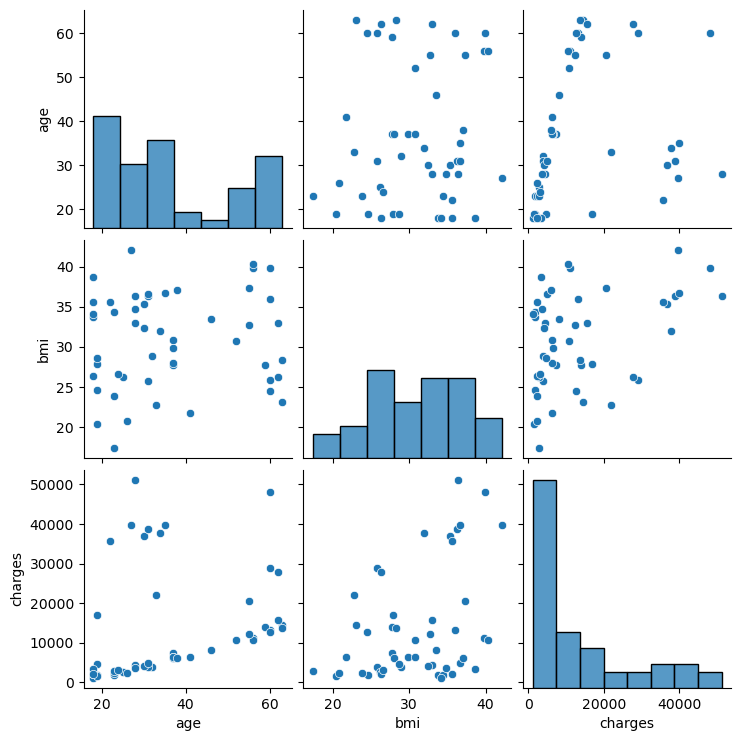

In [64]:
sns.pairplot(df.iloc[0:50][['age', 'bmi', 'charges']])

In [65]:
#splitting the data into dependent dataframe and independent dataframes
y = df['charges']
xvars = ['age', 'bmi', 'children']
X = df[xvars]

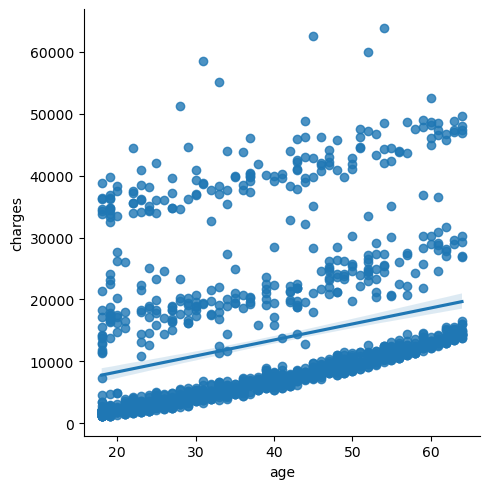

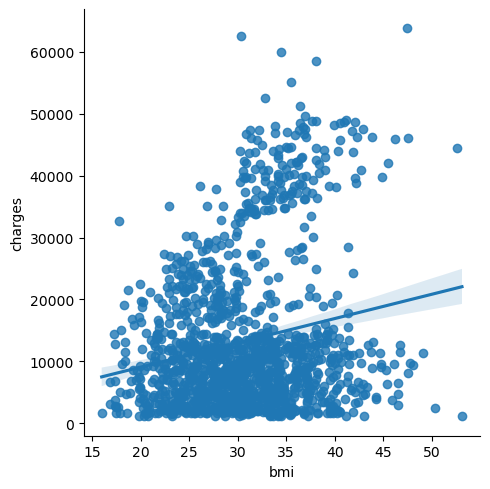

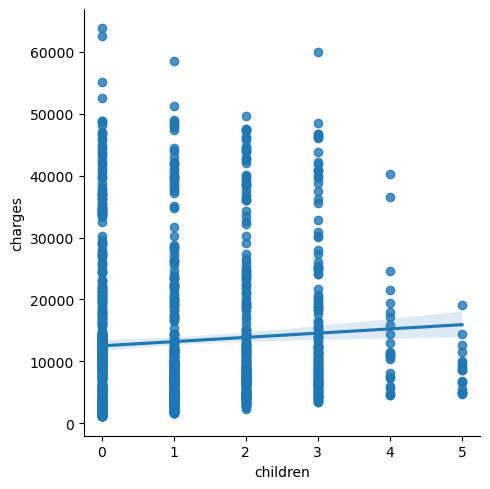

In [66]:
#plotting the independent variables against the dependent variables
for i in xvars:
    sns.lmplot(x=i, y='charges', fit_reg = True, data=df)

In [67]:
#Adding a constant to the independent variables data frame so that the regression includes an intercept term
X = sm.add_constant(X)
X.head()

,const,age,bmi,children
0,1.0,19,27.900,0
1,1.0,18,33.770,1
2,1.0,28,33.000,3
3,1.0,33,22.705,0
4,1.0,32,28.880,0


In [68]:
#model1
model1= sm.OLS.from_formula('charges ~ age + bmi + children',df)
results1= model1.fit()
print(results1.summary())

#stats model1
rsquared1 = results1.rsquared
adj_rsquared1 = results1.rsquared_adj
fstat1 = results1.fvalue
aic1 = results1.aic
bic1 = results1.bic
parameters1 = results1.params
tvalues1 = results1.tvalues
pvalues1 = results1.pvalues
ci1 = results1.conf_int(alpha=0.05)


                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     60.78
Date:                Sun, 28 Sep 2025   Prob (F-statistic):           7.93e-37
Time:                        22:14:09   Log-Likelihood:                -14379.
No. Observations:                1337   AIC:                         2.877e+04
Df Residuals:                    1333   BIC:                         2.879e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -6879.4915   1755.091     -3.920      0.0

In [69]:
#model2
model2= sm.OLS.from_formula('charges ~ age + bmi + children + smoker',df)
results2= model2.fit()
print(results2.summary())

#stats model2
rsquared2 = results2.rsquared
adj_rsquared2 = results2.rsquared_adj
fstat2 = results2.fvalue
aic2 = results2.aic
bic2 = results2.bic
parameters2 = results2.params
tvalues2 = results2.tvalues
pvalues2 = results2.pvalues
ci3 = results2.conf_int(alpha=0.05)

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     993.9
Date:                Sun, 28 Sep 2025   Prob (F-statistic):               0.00
Time:                        22:14:13   Log-Likelihood:                -13541.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1332   BIC:                         2.712e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.209e+04    942.102    -12.832      0.0

In [70]:
df = pd.get_dummies(df, drop_first=True, dtype=int)
df.rename(columns = {'smoker_yes': 'smoker'},inplace = True)
df.head()
df.columns
df.head()

,age,bmi,children,charges,sex_male,smoker,region_northwest,region_southeast,region_southwest,y_hat,e1
0,19,27.900,0,16884.92400,0,1,0,0,1,6908.777533,9976.146467
1,18,33.770,1,1725.55230,1,0,0,1,0,9160.977061,-7435.424761
2,28,33.000,3,4449.46200,1,0,0,1,0,12390.946918,-7941.484918
3,33,22.705,0,21984.47061,1,0,1,0,0,8543.527095,13440.943515
4,32,28.880,0,3866.85520,1,0,1,0,0,10354.147396,-6487.292196


In [71]:
#model3
model3= sm.OLS.from_formula('charges ~ age + bmi + smoker + region_northwest +region_southeast + region_southwest',df)
results3= model3.fit()
print(results3.summary())

#stats model2
rsquared3 = results3.rsquared
adj_rsquared3 = results3.rsquared_adj
fstat3 = results3.fvalue
aic3 = results3.aic
bic3 = results3.bic
parameters3 = results3.params
tvalues3 = results3.tvalues
pvalues3 = results3.pvalues
ci3 = results3.conf_int(alpha=0.05)

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     658.1
Date:                Sun, 28 Sep 2025   Prob (F-statistic):               0.00
Time:                        22:14:18   Log-Likelihood:                -13544.
No. Observations:                1337   AIC:                         2.710e+04
Df Residuals:                    1330   BIC:                         2.714e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        -1.159e+04    976.233  

In [72]:
#model4
model4 = sm.OLS.from_formula('charges ~ age + bmi + smoker + children + np.log(region_northwest + 1) + np.log(region_southeast +1) + np.log(region_southwest + 1)', df)
results4= model4.fit()
print(results4.summary())

#stats model5
rsquared4 = results4.rsquared
adj_rsquared4 = results4.rsquared_adj
fstat4 = results4.fvalue
aic4 = results4.aic
bic4 = results4.bic
parameters4 = results4.params
tvalues4 = results4.tvalues
pvalues4 = results4.pvalues
ci4 = results4.conf_int(alpha=0.05)

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     570.4
Date:                Sun, 28 Sep 2025   Prob (F-statistic):               0.00
Time:                        22:14:22   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1329   BIC:                         2.713e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [73]:
#model5
model5 = sm.OLS.from_formula(
    'charges ~ np.log(age + 1) + np.log(bmi + 1) + np.log(children + 1) + np.log(smoker + 1)+ region_northwest + region_southeast + region_southwest',
    df
)

results5 = model5.fit()
print(results5.summary())

#stats model5
rsquared5 = results5.rsquared
adj_rsquared5 = results5.rsquared_adj
fstat5 = results5.fvalue
aic5 = results5.aic
bic5 = results5.bic
parameters5 = results5.params
tvalues4 = results5.tvalues
pvalues4 = results5.pvalues
ci5 = results5.conf_int(alpha=0.05)

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     552.0
Date:                Sun, 28 Sep 2025   Prob (F-statistic):               0.00
Time:                        22:14:26   Log-Likelihood:                -13554.
No. Observations:                1337   AIC:                         2.712e+04
Df Residuals:                    1329   BIC:                         2.717e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -6.173e+04 

In [74]:
#7 Comparing the models using R Squared, Adjusted R Square, AIC, BIC

models = ['model1', 'model2', 'model3', 'model4', 'model5']
models_rsquared = [rsquared1, rsquared2, rsquared3, rsquared4, rsquared5]
models_adj_rsquared =[adj_rsquared1, adj_rsquared2, adj_rsquared3, adj_rsquared4, adj_rsquared5]
models_aic = [aic1, aic2, aic3, aic4,aic5 ]
models_bic = [bic1, bic2, bic3, aic4, aic5]

data = {
    'Model': models,
    'R-squared': models_rsquared,
    'Adjusted R-squared': models_adj_rsquared,
    'AIC': models_aic,
    'BIC': models_bic
}

df_stats = pd.DataFrame(data)
print(df_stats)

    Model  R-squared  Adjusted R-squared           AIC           BIC
0  model1   0.120322            0.118342  28766.796946  28787.589680
1  model2   0.749045            0.748291  27091.821715  27117.812633
2  model3   0.748026            0.746890  27101.236349  27137.623634
3  model4   0.750259            0.748944  27091.335351  27091.335351
4  model5   0.744069            0.742721  27124.070125  27124.070125


In [17]:
#8 Variance Inflation Factor calculation
#Variance Inflation Factor to check for multicollinearity

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("Variance Inflation Factor (VIF) for Multicollinearity:")
print(vif)


Variance Inflation Factor (VIF) for Multicollinearity:
   Variable        VIF
0     const  31.954929
1       age   1.013816
2       bmi   1.012152
3  children   1.001874


In [18]:
#Correlation matrix to check for multicollinearity.
X.corr() 

,const,age,bmi,children
const,NaN,NaN,NaN,NaN
age,NaN,1.000000,0.109272,0.042469
bmi,NaN,0.109272,1.000000,0.012759
children,NaN,0.042469,0.012759,1.000000


In [19]:
#9 Fitted values y-hat and residuals e

y_hat = results1.fittedvalues
e1= results1.resid

In [20]:
#adding the fitted values and residuals in the dataset
df['y_hat'] = y_hat
df['e1'] = e1
df.head()

,age,bmi,children,charges,sex_male,smoker,region_northwest,region_southeast,region_southwest,y_hat,e1
0,19,27.900,0,16884.92400,0,1,0,0,1,6908.777533,9976.146467
1,18,33.770,1,1725.55230,1,0,0,1,0,9160.977061,-7435.424761
2,28,33.000,3,4449.46200,1,0,0,1,0,12390.946918,-7941.484918
3,33,22.705,0,21984.47061,1,0,1,0,0,8543.527095,13440.943515
4,32,28.880,0,3866.85520,1,0,1,0,0,10354.147396,-6487.292196


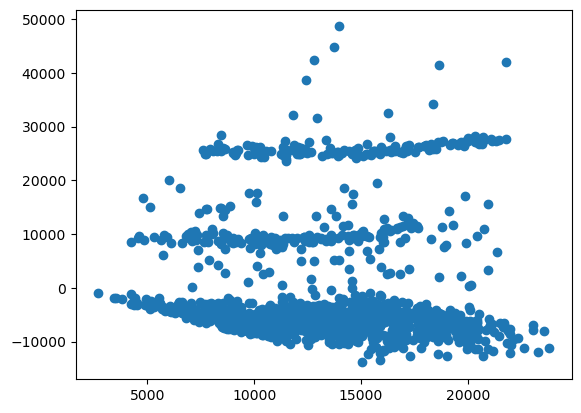

In [21]:
#plotting e in 
plt.scatter(y_hat,e1)

-2.1882252196916372e-11


(array([238., 723.,  30., 154.,  37.,   8., 138.,   4.,   4.,   2.]),
 array([-13883.78364557,  -7632.67386619,  -1381.5640868 ,   4869.54569258,
         11120.65547196,  17371.76525134,  23622.87503072,  29873.9848101 ,
         36125.09458949,  42376.20436887,  48627.31414825]),
 <BarContainer object of 10 artists>)

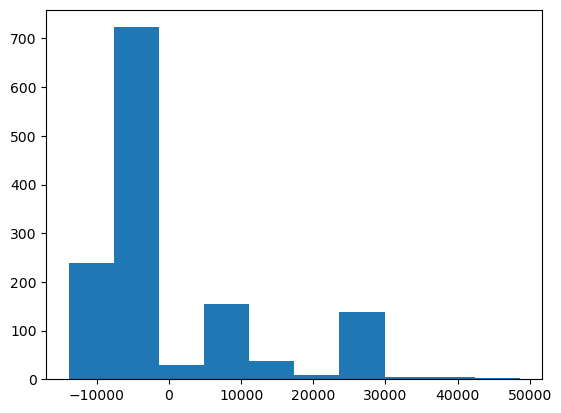

In [22]:
#10 Plotting histogram of residuals

print(e1.mean())
plt.hist(e1)

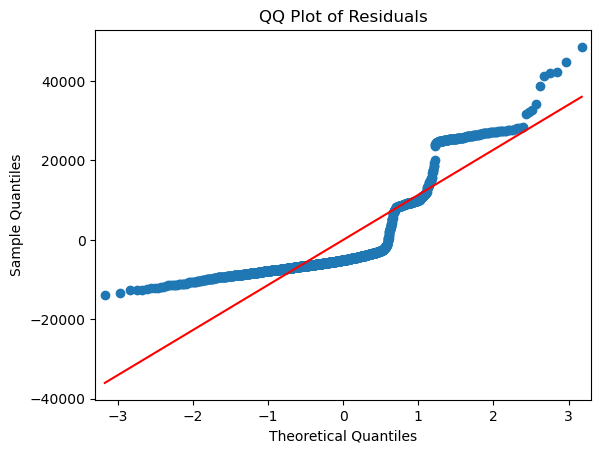

In [23]:
# The data seems to have an outlier but is centered around zero for the most part
# So it is normally distributed but not a complete bell curve
# i will do an additional QQ plot to test for normality

sm.qqplot(results1.resid, line='s', dist=stats.norm)
plt.title("QQ Plot of Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

In [24]:
#11 breusch pagan test for heteroskedasticity
bp_test = het_breuschpagan(e1, X)
print("Breusch Pagan Test P-Value:")
print(bp_test[3])

Breusch Pagan Test P-Value:
2.174680541418531e-30


In [25]:
#12 Standardizing the residuals to check for outliers

residuals_stdev = df['e1'].std()
standardized_residuals = df['e1']/residuals_stdev
#too much long data to print so avoiding this
#print(standardized_residuals)
outliers = np.where(np.abs(standardized_residuals) > 3)[0]
outliers

array([  34,  543,  577,  819, 1146, 1230, 1300])

In [26]:
#removing the outliers
df.drop(index=49, inplace = True)

In [27]:
#checking if the row was removed
df.tail()

,age,bmi,children,charges,sex_male,smoker,region_northwest,region_southeast,region_southwest,y_hat,e1
1333,50,30.97,3,10600.5483,1,0,1,0,0,16996.696122,-6396.147822
1334,18,31.92,0,2205.9808,0,0,0,0,0,8003.758184,-5797.777384
1335,18,36.85,0,1629.8335,0,0,0,1,0,9640.929171,-8011.095671
1336,21,25.80,0,2007.9450,0,0,0,0,1,6691.391417,-4683.446417
1337,61,29.07,0,29141.3603,0,1,1,0,0,17377.082990,11764.277310


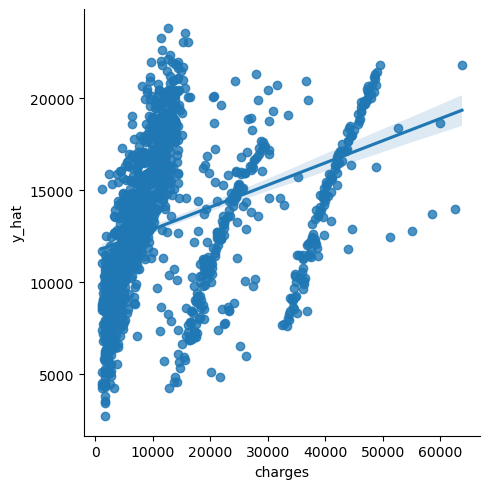

In [28]:
#13 scatter plot with a trend line
sns.lmplot(x='charges', y='y_hat', fit_reg = True, data=df)

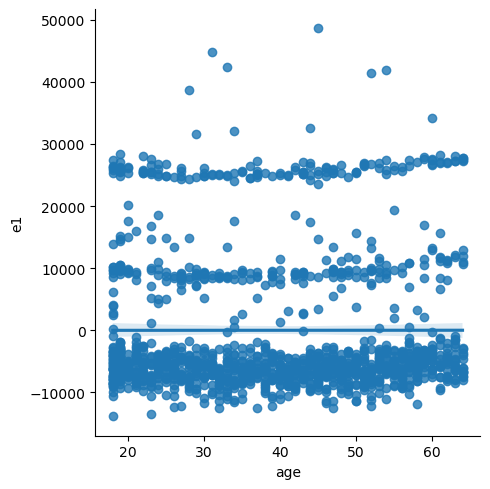

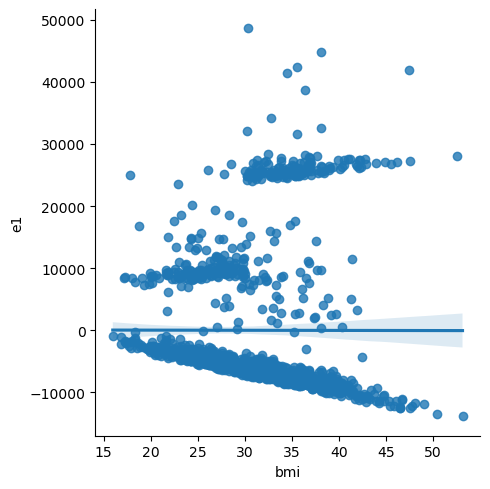

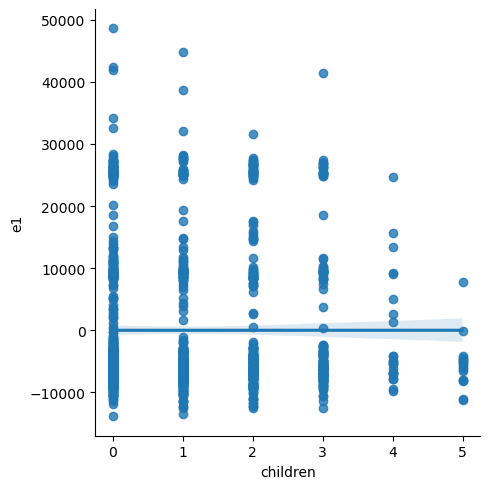

In [29]:
#14 plotting residuals against x-variaables
for var in xvars:
    sns.lmplot(x=var,y='e1', fit_reg=True, data=df) 

In [30]:
#15 Predictions for hypothetical dataset

prediction = pd.DataFrame({
    'age': [25, 40, 55],
    'bmi': [22, 28, 35],
    'smoker': [0, 1, 0],
    'children' : [0,1,3],
    'region_northwest': [0, 1, 0],
    'region_southeast': [1, 0, 0],
    'region_southwest': [0, 0, 1]
    
})

prediction = sm.add_constant(prediction)
prediction ['charges'] =  results1.predict(prediction)
print(prediction)

   const  age  bmi  smoker  children  region_northwest  region_southeast  \
0    1.0   25   22       0         0                 0                 1   
1    1.0   40   28       1         1                 1                 0   
2    1.0   55   35       0         3                 0                 0   

   region_southwest       charges  
0                 0   6389.452529  
1                 0  12524.734482  
2                 1  19534.964453  


In [34]:
y_true = df['charges']               
y_pred = results5.predict(df)  
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
accuracy = 100 - mape
print("MAPE:", mape, "%")
print("Approximate Accuracy:", accuracy, "%")

MAPE: 99.85579233273995 %
Approximate Accuracy: 0.14420766726004786 %
